In [ ]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 66.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 77.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]ow]

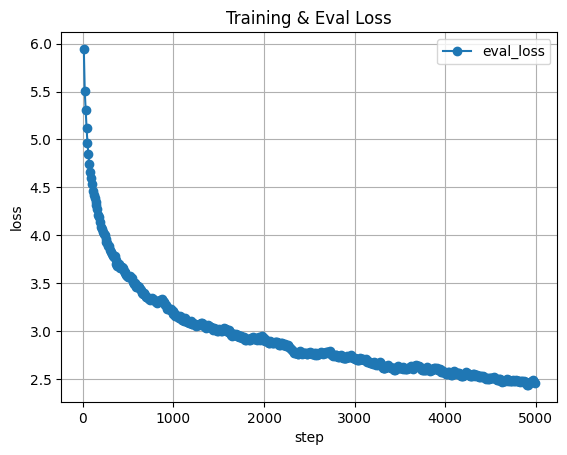

In [9]:
import re
import matplotlib.pyplot as plt

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

with open('/Users/xuge/cs336/checkpoints/debug/training_log.txt') as f:
  for line in f:
      m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
      if m:
          train_steps.append(int(m.group(1)))
          train_losses.append(float(m.group(2)))
          continue
      m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
      if m:
          eval_steps.append(int(m.group(1)))
          eval_losses.append(float(m.group(2)))

plt.plot(train_steps, train_losses, label='train_loss')
plt.plot(eval_steps, eval_losses, label='eval_loss', marker='o')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training & Eval Loss')
plt.legend()
plt.grid(True)
plt.show()

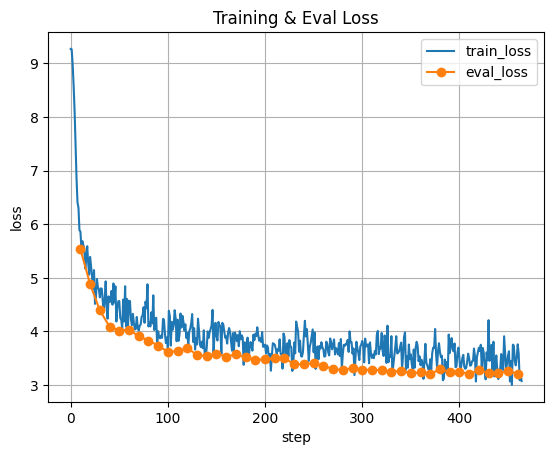

In [12]:
import re
import matplotlib.pyplot as plt

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

with open('/Users/xuge/cs336/checkpoints/debug/438e2311-6f64-4957-866e-9cccbce88332/training_log.txt') as f:
  for line in f:
      m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
      if m:
          train_steps.append(int(m.group(1)))
          train_losses.append(float(m.group(2)))
          continue
      m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
      if m:
          eval_steps.append(int(m.group(1)))
          eval_losses.append(float(m.group(2)))

plt.plot(train_steps, train_losses, label='train_loss')
plt.plot(eval_steps, eval_losses, label='eval_loss', marker='o')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training & Eval Loss')
plt.legend()
plt.grid(True)
plt.show()

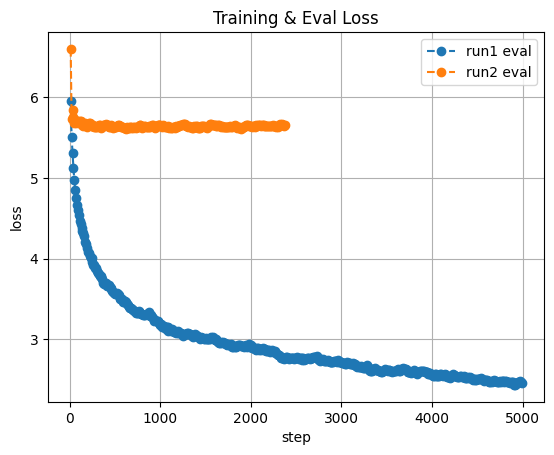

In [10]:
def parse_log(path):
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    with open(path) as f:
        for line in f:
            m = re.match(r'step=(\d+)\s+train_loss=([\d.]+)', line)
            if m:
                train_steps.append(int(m.group(1)))
                train_losses.append(float(m.group(2)))
                continue
            m = re.match(r'step=(\d+)\s+eval_loss=([\d.]+)', line)
            if m:
                eval_steps.append(int(m.group(1)))
                eval_losses.append(float(m.group(2)))
    return train_steps, train_losses, eval_steps, eval_losses


def plot_runs(runs, show_train=False, show_eval=True, title='Training & Eval Loss'):
    """Plot train and/or eval loss curves for one or more runs.

    Args:
        runs: dict mapping run name -> path to training_log.txt
        show_train: if True, plot train loss curves
        show_eval: if True, plot eval loss curves
        title: plot title
    """
    for i, (name, path) in enumerate(runs.items()):
        c = f'C{i % 10}'
        ts, tl, es, el = parse_log(path)
        if show_train:
            plt.plot(ts, tl, color=c, label=f'{name} train')
        if show_eval:
            plt.plot(es, el, color=c, linestyle='--', marker='o', label=f'{name} eval')

    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


runs = {
    'run1': '/Users/xuge/cs336/checkpoints/debug/training_log.txt',
    'run2': '/Users/xuge/cs336/checkpoints/debug/50390296-ade0-4a47-9d96-fe40ce0337af/training_log.txt',
}
plot_runs(runs)

Uv run python -m tests.train_together \
    --vocab_size 10000 \
    --context_length 256 \
    --d_model 512 \
    --d_ff 1344 \
    --num_layers 4 \
    --num_heads 16 \
    --rope_theta 10000 \
    --batch_size 8 \
    --eval_batch_size 2 \
    --num_steps 5000 \
    --log_interval 1 \
    --eval_interval 10 \
    --num_warmup_steps 5 \
    --cosine_cycle_iters 5000 \
    --max_lr 0.0015 \
    --min_lr 0.00015 \
    --device mps \
    --train_data ./tinystories_train.bin \
    --eval_data ./tinystories_valid.bin \
    --checkpoint_dir ./checkpoints/debug 

In [28]:
4 * 5000 * 256

5120000

In [31]:

327_680_000 / 512000

640.0

In [73]:
!Uv run python -m tests.decoding \
    --checkpoint ./checkpoints/debug/d1acf839-5ee1-48ed-b3d0-bf45237b7750/checkpoint_step_0005000.pt \
    --prompt "elene goes to a small hut"

torch.Size([1, 10000])
torch.Size([1])
torch.Size([8])


Q: Remove RMSNorm and train 
A: Training loss spikes a lot probably because of expoloading gradients. becuase each layer add residual streams, after 4 layers, it becomes larger and larger. Huge loss value causes huge gradient and the training to be weird 

Problem (pre_norm_ablation): Implement post-norm and train (0.5 B200 hrs) (1 point)
Modify your pre-norm Transformer implementation into a post-norm one. Train with the post-
norm model and see what happens.
Deliverable: A learning curve for a post-norm Transformer, compared to the pre-norm one.


foward function changed to :     def forward(self, in_features: torch.Tensor, token_positions) -> torch.Tensor:
        x = in_features
        t = self.attn(x, token_positions)
        z = x + t
        z = self.ln1(z)
        y = self.ln2(self.ffn(z) + z)
        return y





guid: 50390296-ade0-4a47-9d96-fe40ce0337af
Converges much slower. After 2500 runs loss is still 5.6 ish 


    

Problem (no_pos_emb): Implement NoPE (0.5 B200 hrs) (1 point)
Modify your Transformer implementation with RoPE to remove the position embedding
information entirely, and see what happens.
Deliverable: A learning curve comparing the performance of RoPE and NoPE.
 
#Rope run: b357959f-73ab-49d4-b40a-dbb50a7ec862
#Nope run: e3854d61-246b-482e-bfa5-39c575eca5aa



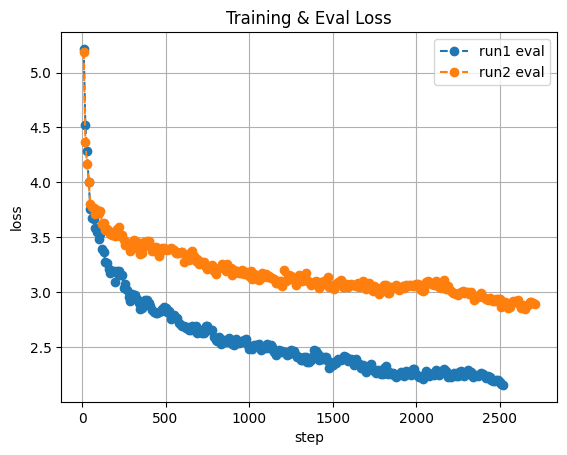

In [13]:
runs = {
    'run1': '/Users/xuge/cs336/checkpoints/debug/b357959f-73ab-49d4-b40a-dbb50a7ec862/training_log.txt',
    'run2': '/Users/xuge/cs336/checkpoints/debug/e3854d61-246b-482e-bfa5-39c575eca5aa/training_log.txt',
}
plot_runs(runs)


Problem (swiglu_ablation): SwiGLU vs. SiLU (0.5 B200 hrs) (1 point)
43
Deliverable: A learning curve comparing the performance of SwiGLU and SiLU feed-forward
networks, with approximately matched parameter counts.
Deliverable: A few sentences discussing your findings.



Silu command (Don't forget the d_ff!): 

Uv run python -m tests.train_together \
    --vocab_size 10000 \
    --context_length 256 \
    --d_model 512 \
    --d_ff 2048 \
    --num_layers 4 \
    --num_heads 16 \
    --rope_theta 10000 \
    --batch_size 8 \
    --eval_batch_size 2 \
    --num_steps 5000 \
    --log_interval 1 \
    --eval_interval 10 \
    --num_warmup_steps 5 \
    --cosine_cycle_iters 5000 \
    --max_lr 0.0015 \
    --min_lr 0.00015 \
    --device mps \
    --train_data ./tinystories_train.bin \
    --eval_data ./tinystories_valid.bin \
    --checkpoint_dir ./checkpoints/debug 
    


Swiglu:  b357959f-73ab-49d4-b40a-dbb50a7ec862
Silu: af372d76-25a7-4ffe-ba97-03a771c8d335


The performance is pretty much the same. matrix mult per batch per token:

Swiglu: 2*d_ff*d_model* d_model * 3, d_ff = 8/3 d_model
Silu: 2* d_ff * d_model d_ff = 4 d_model

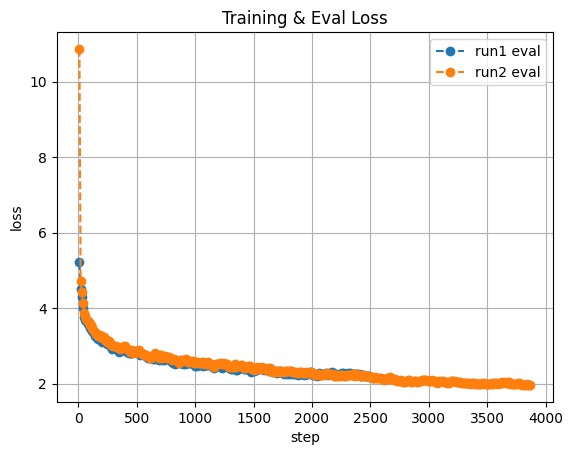

In [22]:
runs = {
    'run1': '/Users/xuge/cs336/checkpoints/debug/b357959f-73ab-49d4-b40a-dbb50a7ec862/training_log.txt',
    'run2': '/Users/xuge/cs336/checkpoints/debug/af372d76-25a7-4ffe-ba97-03a771c8d335/training_log.txt',
}
plot_runs(runs, show_train = False)
